In [1]:
import os
import tempfile
from matplotlib import pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
import pickle

In [2]:
data_dir = "./data"
x_list = []
y_list = []
batch_size = 32

In [3]:
for file in os.listdir(data_dir):
    path = os.path.join(data_dir, file)
    with open (path, 'rb') as fo:
        data_dict = pickle.load(fo, encoding='bytes')
        
        x_list.append(data_dict[b'data'])
        y_list.extend(data_dict[b'labels'])



C:\Users\xavif\AppData\Local\Temp\ipykernel_23312\1666005491.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data_dict = pickle.load(fo, encoding='bytes')


In [4]:
X = np.concatenate(x_list)
Y = np.array(y_list)

In [5]:
print(data_dict.keys())

dict_keys([b'batch_label', b'labels', b'data', b'filenames'])


In [6]:
X = X.reshape(-1, 3, 32, 32)
X = X.transpose(0, 2, 3, 1)
X = X.astype(float) / 255.0


### Normalización

### One hot encoding

In [7]:
y = to_categorical(Y, 10)

In [8]:
print(X.shape)  # por ejemplo: (50000, 3072)
print(y.shape)  # por ejemplo: (50000,)

(50000, 32, 32, 3)
(50000, 10)


### Separación de train y test

In [9]:
dataset = tf.data.Dataset.from_tensor_slices((X, y))

dataset = dataset.shuffle(buffer_size=len(X), seed=42)

In [10]:
train_size = int(0.8 * len(X))

In [11]:
train_dataset = dataset.take(train_size)
val_dataset = dataset.skip(train_size)

In [12]:
train_dataset = train_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Red neuronal

In [13]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(32,activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

c:\Users\xavif\Documents\MASTER\MobileNet-TransferLearning\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


In [ ]:
history = model.fit(train_dataset, epochs=15, batch_size=64,
                    validation_data=val_dataset)

Epoch 1/10


c:\Users\xavif\Documents\MASTER\MobileNet-TransferLearning\.venv\Lib\site-packages\keras\src\backend\tensorflow\nn.py:1172: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.4039 - loss: 1.6209 - val_accuracy: 0.5432 - val_loss: 1.2934
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.5565 - loss: 1.2399 - val_accuracy: 0.5959 - val_loss: 1.1416
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.6131 - loss: 1.0912 - val_accuracy: 0.6196 - val_loss: 1.0760
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.6523 - loss: 0.9866 - val_accuracy: 0.6749 - val_loss: 0.9136
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6769 - loss: 0.9117 - val_accuracy: 0.7056 - val_loss: 0.8249
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.7039 - loss: 0.8442 - val_accuracy: 0.7275 - val_loss: 0.7657
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.7258 - loss: 0.7853 - val_accuracy: 0.7508 - val_loss: 0.7185
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.7378 - loss: 0.73

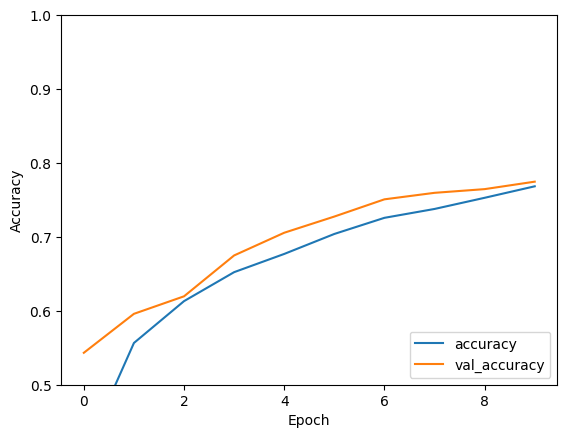

In [16]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1)
plt.legend(loc='lower right')